# 04b Saved 04a Model - Dataset 1 and Dataset 2

Simple experiment using the best classical-feature model saved from notebook 04.

- Dataset 1: keep the same temporal split structure as notebook 04 and retrain the saved model pipeline for each p-threshold target.
- Dataset 2: run two experiments: retrain on a random split, and direct prediction using the saved 04a model without retraining.
- The p-threshold plots include the baseline as `p0`.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
from src.models.ml_train_and_store import (
    CLASSICAL_FEATURE_CANDIDATES,
    load_classical_dataset,
    load_model,
    top1_bank_cohort,
    top1_metrics,
)

PROJECT_ROOT = find_project_root()
MODEL_PATH = PROJECT_ROOT / 'src' / 'models' / 'dataset_1' / '04_a' / 'Gradient_Boosting_(tuned).joblib'
DATASET2_FEATURES_PATH = PROJECT_ROOT / 'src' / 'data' / 'classical_features' / 'dataset_2' / 'classical_features_dataset2.parquet'
DATASET2_TARGETS_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_2' / 'targets'
TARGETS_DIR = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_1' / 'targets'
OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'predictions' / '04b_saved_04a'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'log_systemic_risk_label'
RANDOM_STATE = 42
TARGET_DISTRIBUTION_BINS = 10
ROUND_DECIMALS = 3
TRAIN_END_YEAR = 2021
TRAIN_END_QUARTER = 4
METRIC_COLUMNS = [
    'train_rmse', 'validation_rmse',
    'train_mae', 'validation_mae',
    'train_top1_rmse', 'validation_top1_rmse',
    'train_top1_mae', 'validation_top1_mae',
]

pd.set_option('display.max_columns', 120)
print(PROJECT_ROOT)

/Users/rubenmarques/Documents/Repositórios/Thesis


## Inputs

In [2]:
P_LABELS = ['p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']

dataset1_target_dirs = {
    'dataset1_baseline': TARGETS_DIR,
    **{f'dataset1_{p}': TARGETS_DIR / p for p in P_LABELS},
}

dataset2_target_files = {
    'dataset2_baseline': DATASET2_TARGETS_DIR / 'target.csv',
    **{f'dataset2_{p}': DATASET2_TARGETS_DIR / f'target_{p}.csv' for p in P_LABELS},
}

model = load_model(MODEL_PATH)
models = {'Gradient Boosting (tuned)': model}

print('Model:', MODEL_PATH.name)
print('Dataset 1 targets:', len(dataset1_target_dirs))
print('Dataset 2 targets:', len(dataset2_target_files))

Model: Gradient_Boosting_(tuned).joblib
Dataset 1 targets: 9
Dataset 2 targets: 9


## Helpers

In [3]:
def load_dataset1(target_dir):
    df, feature_cols = load_classical_dataset(
        PROJECT_ROOT,
        target_col=TARGET_COL,
        target_dir=target_dir,
    )
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    return df, feature_cols


def load_dataset2(target_path):
    features = pd.read_parquet(DATASET2_FEATURES_PATH).copy()
    targets = pd.read_csv(target_path)
    df = features.merge(targets, on='bank_id', how='inner')
    feature_cols = [c for c in CLASSICAL_FEATURE_CANDIDATES if c in df.columns]
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    return df, feature_cols


def temporal_split(df):
    keyed = df.copy()
    keyed['_key'] = keyed['year'] * 10 + keyed['quarter']

    train_df = keyed[keyed['_key'] <= 20214].drop(columns='_key')
    val_df = keyed[(keyed['_key'] > 20214) & (keyed['_key'] <= 20224)].drop(columns='_key')
    test_df = keyed[(keyed['_key'] > 20224) & (keyed['_key'] <= 20233)].drop(columns='_key')

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def make_stratify_bins(df, max_bins=TARGET_DISTRIBUTION_BINS):
    y = df[TARGET_COL]
    max_bins = min(max_bins, y.nunique())

    for n_bins in range(max_bins, 1, -1):
        try:
            bins = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            continue

        counts = pd.Series(bins).value_counts()
        if len(counts) > 1 and counts.min() >= 2:
            return bins

    return None


def random_split(df):
    stratify_bins = make_stratify_bins(df)
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=stratify_bins,
    )

    val_stratify_bins = make_stratify_bins(train_val_df)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.15 / 0.85,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=val_stratify_bins,
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
    }


def add_predictions(dataset_name, experiment, model_name, split_name, split_df, fitted_model, feature_cols):
    id_cols = [c for c in ['bank_id', 'year', 'quarter', 'period'] if c in split_df.columns]
    pred_df = split_df[id_cols + [TARGET_COL]].copy()
    pred_df['prediction'] = fitted_model.predict(split_df[feature_cols])
    pred_df['abs_error'] = (pred_df[TARGET_COL] - pred_df['prediction']).abs()
    pred_df.insert(0, 'split', split_name)
    pred_df.insert(0, 'model', model_name)
    pred_df.insert(0, 'experiment', experiment)
    pred_df.insert(0, 'dataset', dataset_name)
    return pred_df


def fit_and_score(dataset_name, experiment, feature_cols, train_df, val_df, test_df, cohort=None):
    # Pass cohort=set() to skip top-1% scoring (used for dataset 2 where each bank has 1 row).
    if cohort is None:
        cohort = top1_bank_cohort(train_df, TARGET_COL)

    rows = []
    preds = []

    for model_name, saved_model in models.items():
        fitted_model = clone(saved_model)
        fitted_model.fit(train_df[feature_cols], train_df[TARGET_COL])

        row = {'dataset': dataset_name, 'experiment': experiment, 'model': model_name}
        for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
            y_pred = fitted_model.predict(split_df[feature_cols])
            split_metrics = metrics(split_df[TARGET_COL], y_pred)
            split_top1_metrics = top1_metrics(split_df, y_pred, cohort, TARGET_COL)
            row[f'{split_name}_mae'] = split_metrics['mae']
            row[f'{split_name}_rmse'] = split_metrics['rmse']
            row[f'{split_name}_top1_mae'] = split_top1_metrics['mae']
            row[f'{split_name}_top1_rmse'] = split_top1_metrics['rmse']
            preds.append(add_predictions(dataset_name, experiment, model_name, split_name, split_df, fitted_model, feature_cols))

        rows.append(row)

    return rows, preds


def prepare_metric_table(df):
    df = df.copy()
    df = df.drop(columns=[col for col in df.columns if col.endswith('_r2')], errors='ignore')

    metric_cols = [col for col in df.columns if any(name in col for name in ['rmse', 'mae'])]
    df[metric_cols] = df[metric_cols].round(ROUND_DECIMALS)

    id_cols = ['dataset', 'experiment', 'model']
    ordered_cols = [col for col in [*id_cols, *METRIC_COLUMNS] if col in df.columns]
    other_cols = [col for col in df.columns if col not in ordered_cols]
    return df[ordered_cols + other_cols]


def predict_with_saved_model(dataset_name, df, feature_cols, cohort=None):
    # Pass cohort=set() to skip top-1% scoring.
    if cohort is None:
        cohort = top1_bank_cohort(df, TARGET_COL)

    rows = []
    preds = []

    for model_name, fitted_model in models.items():
        y_pred = fitted_model.predict(df[feature_cols])
        score = metrics(df[TARGET_COL], y_pred)
        score_top1 = top1_metrics(df, y_pred, cohort, TARGET_COL)
        rows.append({
            'dataset': dataset_name,
            'experiment': 'dataset2_loaded_04a_only',
            'model': model_name,
            'test_mae': score['mae'],
            'test_rmse': score['rmse'],
            'test_top1_mae': score_top1['mae'],
            'test_top1_rmse': score_top1['rmse'],
        })
        preds.append(add_predictions(dataset_name, 'dataset2_loaded_04a_only', model_name, 'all', df, fitted_model, feature_cols))

    return rows, preds

## Dataset 1 - temporal split, retrain saved pipeline

In [4]:
all_rows = []
all_predictions = []

for dataset_name, target_dir in dataset1_target_dirs.items():
    df, feature_cols = load_dataset1(target_dir)
    train_df, val_df, test_df = temporal_split(df)
    rows, preds = fit_and_score(
        dataset_name, 'dataset1_temporal_train_04a_specs', feature_cols, train_df, val_df, test_df
    )
    all_rows.extend(rows)
    all_predictions.extend(preds)

dataset1_results = prepare_metric_table(pd.DataFrame(all_rows))
display(dataset1_results.sort_values(['dataset', 'validation_rmse']))

,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset1_baseline,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.060,0.083,0.010,0.015,0.420,0.592,0.313,0.480,0.012,0.070,0.366,0.451
2,dataset1_p10,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.060,0.084,0.010,0.015,0.410,0.563,0.299,0.462,0.013,0.070,0.359,0.439
3,dataset1_p15,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.061,0.086,0.010,0.016,0.406,0.569,0.294,0.471,0.013,0.071,0.360,0.445
4,dataset1_p20,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.066,0.084,0.011,0.016,0.433,0.536,0.319,0.447,0.013,0.070,0.349,0.426
5,dataset1_p25,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.065,0.084,0.011,0.017,0.428,0.516,0.307,0.421,0.013,0.070,0.340,0.413
6,dataset1_p30,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.065,0.083,0.012,0.017,0.413,0.495,0.299,0.405,0.014,0.071,0.313,0.383
7,dataset1_p35,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.068,0.083,0.012,0.017,0.431,0.483,0.309,0.396,0.014,0.073,0.326,0.398
8,dataset1_p40,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.070,0.082,0.013,0.017,0.439,0.468,0.308,0.378,0.015,0.074,0.308,0.379
1,dataset1_p5,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.062,0.083,0.010,0.015,0.426,0.578,0.317,0.475,0.012,0.069,0.351,0.431


## Dataset 2 - random split, retrain saved pipeline

In [5]:
dataset2_train_rows = []

for dataset_name, target_path in dataset2_target_files.items():
    df, feature_cols = load_dataset2(target_path)
    train_df, val_df, test_df = random_split(df)
    rows, preds = fit_and_score(
        dataset_name, 'dataset2_random_train_04a_specs', feature_cols, train_df, val_df, test_df,
        cohort=set(),  # skip top-1% on dataset 2 (1 row per bank, no cross-split overlap)
    )
    dataset2_train_rows.extend(rows)
    all_predictions.extend(preds)

dataset2_train_results = prepare_metric_table(pd.DataFrame(dataset2_train_rows))
display(dataset2_train_results.sort_values(['dataset', 'validation_rmse']))

,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset2_baseline,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.062,0.177,0.017,0.067,NaN,NaN,NaN,NaN,0.054,0.151,NaN,NaN
2,dataset2_p10,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.062,0.216,0.018,0.080,NaN,NaN,NaN,NaN,0.064,0.181,NaN,NaN
3,dataset2_p15,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.063,0.216,0.019,0.080,NaN,NaN,NaN,NaN,0.068,0.191,NaN,NaN
4,dataset2_p20,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.070,0.240,0.021,0.090,NaN,NaN,NaN,NaN,0.069,0.180,NaN,NaN
5,dataset2_p25,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.069,0.201,0.022,0.080,NaN,NaN,NaN,NaN,0.096,0.250,NaN,NaN
6,dataset2_p30,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.066,0.258,0.022,0.092,NaN,NaN,NaN,NaN,0.078,0.217,NaN,NaN
7,dataset2_p35,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.069,0.285,0.025,0.093,NaN,NaN,NaN,NaN,0.080,0.230,NaN,NaN
8,dataset2_p40,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.088,0.223,0.029,0.077,NaN,NaN,NaN,NaN,0.086,0.243,NaN,NaN
1,dataset2_p5,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.062,0.175,0.017,0.068,NaN,NaN,NaN,NaN,0.059,0.165,NaN,NaN


## Dataset 2 - loaded 04a model only, no retraining

In [6]:
dataset2_loaded_rows = []

for dataset_name, target_path in dataset2_target_files.items():
    df, feature_cols = load_dataset2(target_path)
    rows, preds = predict_with_saved_model(dataset_name, df, feature_cols, cohort=set())
    dataset2_loaded_rows.extend(rows)
    all_predictions.extend(preds)

dataset2_loaded_results = prepare_metric_table(pd.DataFrame(dataset2_loaded_rows))
display(dataset2_loaded_results.sort_values(['dataset']))

,dataset,experiment,model,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset2_baseline,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.145,0.213,NaN,NaN
2,dataset2_p10,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.148,0.238,NaN,NaN
3,dataset2_p15,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.150,0.243,NaN,NaN
4,dataset2_p20,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.153,0.254,NaN,NaN
5,dataset2_p25,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.155,0.259,NaN,NaN
6,dataset2_p30,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.159,0.269,NaN,NaN
7,dataset2_p35,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.162,0.281,NaN,NaN
8,dataset2_p40,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.168,0.307,NaN,NaN
1,dataset2_p5,dataset2_loaded_04a_only,Gradient Boosting (tuned),0.146,0.219,NaN,NaN


## Save outputs

In [7]:
results = pd.concat(
    [dataset1_results, dataset2_train_results, dataset2_loaded_results],
    ignore_index=True,
    sort=False,
)
results = prepare_metric_table(results)
predictions = pd.concat(all_predictions, ignore_index=True)

results_path = OUT_DIR / 'metrics.csv'
predictions_path = OUT_DIR / 'predictions.csv'

results.to_csv(results_path, index=False)
predictions.to_csv(predictions_path, index=False)

print(f'Saved metrics: {results_path}')
print(f'Saved predictions: {predictions_path}')

display(results.sort_values(['dataset', 'experiment']))

Saved metrics: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/04b_saved_04a/metrics.csv
Saved predictions: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/04b_saved_04a/predictions.csv


,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae,test_mae,test_rmse,test_top1_mae,test_top1_rmse
0,dataset1_baseline,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.060,0.083,0.010,0.015,0.420,0.592,0.313,0.480,0.012,0.070,0.366,0.451
2,dataset1_p10,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.060,0.084,0.010,0.015,0.410,0.563,0.299,0.462,0.013,0.070,0.359,0.439
3,dataset1_p15,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.061,0.086,0.010,0.016,0.406,0.569,0.294,0.471,0.013,0.071,0.360,0.445
4,dataset1_p20,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.066,0.084,0.011,0.016,0.433,0.536,0.319,0.447,0.013,0.070,0.349,0.426
5,dataset1_p25,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.065,0.084,0.011,0.017,0.428,0.516,0.307,0.421,0.013,0.070,0.340,0.413
6,dataset1_p30,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.065,0.083,0.012,0.017,0.413,0.495,0.299,0.405,0.014,0.071,0.313,0.383
7,dataset1_p35,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.068,0.083,0.012,0.017,0.431,0.483,0.309,0.396,0.014,0.073,0.326,0.398
8,dataset1_p40,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.070,0.082,0.013,0.017,0.439,0.468,0.308,0.378,0.015,0.074,0.308,0.379
1,dataset1_p5,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.062,0.083,0.010,0.015,0.426,0.578,0.317,0.475,0.012,0.069,0.351,0.431
18,dataset2_baseline,dataset2_loaded_04a_only,Gradient Boosting (tuned),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.145,0.213,NaN,NaN


## P-threshold comparison plots

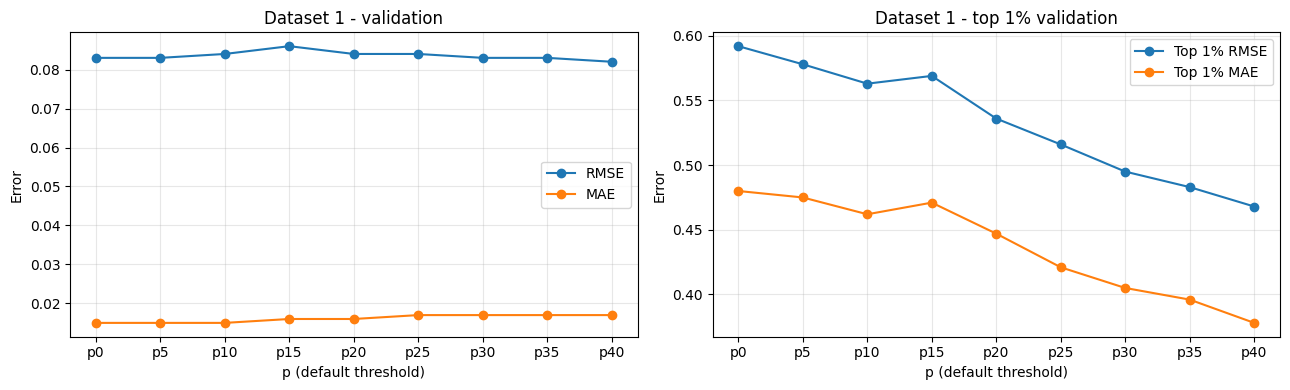

,p,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.083,0.015,0.592,0.480
8,p5,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.083,0.015,0.578,0.475
1,p10,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.084,0.015,0.563,0.462
2,p15,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.086,0.016,0.569,0.471
3,p20,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.084,0.016,0.536,0.447
4,p25,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.084,0.017,0.516,0.421
5,p30,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.083,0.017,0.495,0.405
6,p35,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.083,0.017,0.483,0.396
7,p40,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.082,0.017,0.468,0.378


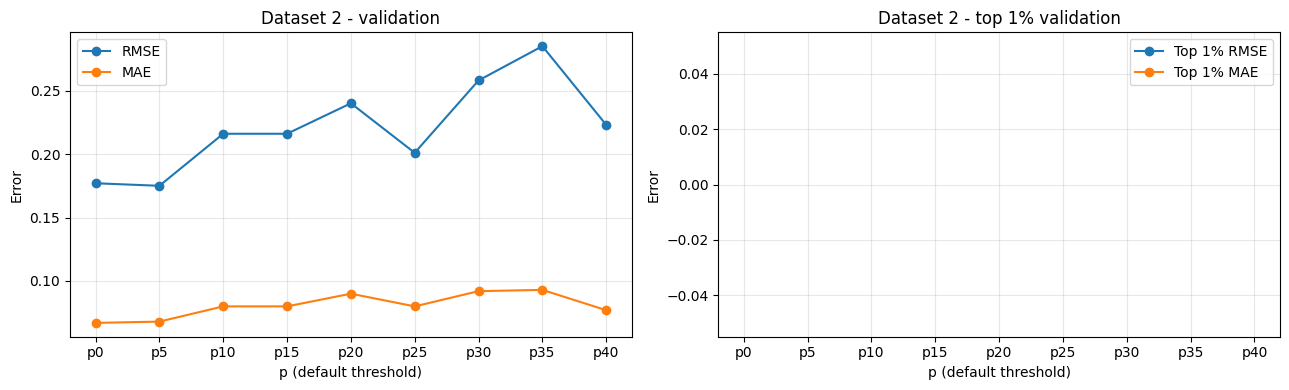

,p,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.177,0.067,NaN,NaN
8,p5,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.175,0.068,NaN,NaN
1,p10,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.216,0.080,NaN,NaN
2,p15,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.216,0.080,NaN,NaN
3,p20,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.240,0.090,NaN,NaN
4,p25,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.201,0.080,NaN,NaN
5,p30,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.258,0.092,NaN,NaN
6,p35,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.285,0.093,NaN,NaN
7,p40,dataset2_random_train_04a_specs,Gradient Boosting (tuned),0.223,0.077,NaN,NaN


In [8]:
def prepare_p_plot_data(results_df, dataset_prefix):
    baseline_name = f'{dataset_prefix}_baseline'
    is_baseline = results_df['dataset'].eq(baseline_name)
    is_p = results_df['dataset'].str.startswith(f'{dataset_prefix}_p')
    plot_df = results_df[is_baseline | is_p].copy()

    plot_df['p'] = plot_df['dataset'].str.extract(r'_(p\d+)$')[0]
    plot_df.loc[plot_df['dataset'].eq(baseline_name), 'p'] = 'p0'
    plot_df['p_num'] = plot_df['p'].str.extract(r'p(\d+)').astype(int)

    best = (
        plot_df.sort_values(['dataset', 'validation_rmse', 'validation_mae'])
        .groupby('dataset', as_index=False)
        .first()
        .sort_values('p_num')
    )
    return best


def plot_p_comparison(results_df, dataset_prefix, title):
    best = prepare_p_plot_data(results_df, dataset_prefix)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

    axes[0].plot(best['p'], best['validation_rmse'], marker='o', label='RMSE')
    axes[0].plot(best['p'], best['validation_mae'], marker='o', label='MAE')
    axes[0].set_title(f'{title} - validation')
    axes[0].set_xlabel('p (default threshold)')
    axes[0].set_ylabel('Error')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(best['p'], best['validation_top1_rmse'], marker='o', label='Top 1% RMSE')
    axes[1].plot(best['p'], best['validation_top1_mae'], marker='o', label='Top 1% MAE')
    axes[1].set_title(f'{title} - top 1% validation')
    axes[1].set_xlabel('p (default threshold)')
    axes[1].set_ylabel('Error')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

    display_cols = [
        'p', 'experiment', 'model',
        'validation_rmse', 'validation_mae', 'validation_top1_rmse', 'validation_top1_mae',
    ]
    display(best[display_cols])


plot_p_comparison(results, 'dataset1', 'Dataset 1')
plot_p_comparison(results, 'dataset2', 'Dataset 2')